In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.datasets import mnist

In [6]:
(x_train,y_train),(x_test,y_test) = mnist.load_data()

In [7]:
x_train.shape

(60000, 28, 28)

In [8]:
y_train.shape

(60000,)

In [9]:
x_test.shape

(10000, 28, 28)

In [10]:
y_test.shape

(10000,)

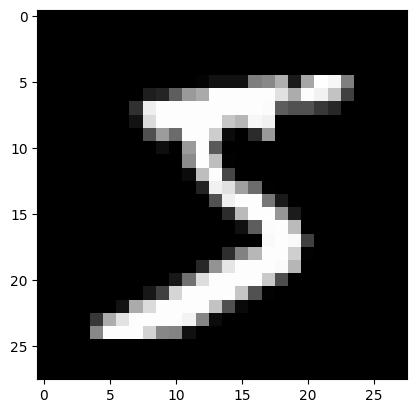

In [11]:
plt.imshow(x_train[0],cmap='gray')
plt.show()

In [12]:
print('label : ',y_train[0])

label :  5


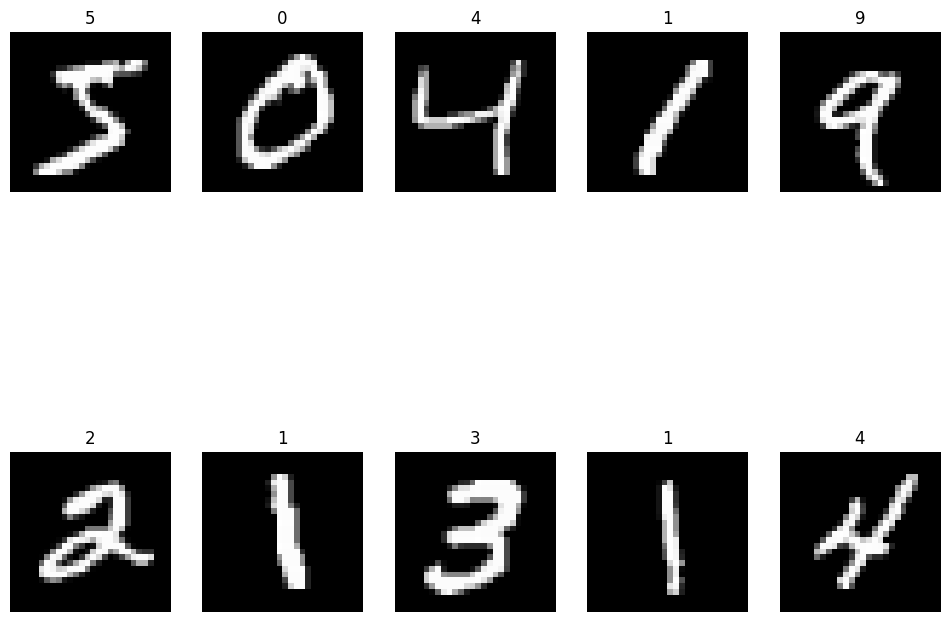

In [15]:
plt.figure(figsize=(12,10))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i],cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.show()   

In [16]:
x_train.min()

0

In [17]:
x_train.max()

255

In [18]:
x_train = x_train /  255
x_test = x_test / 255

In [19]:
x_train.min()

0.0

In [20]:
x_train.max()

1.0

In [21]:
x_train = x_train.reshape(-1,28,28,1)

In [22]:
x_test = x_test.reshape(-1,28,28,1)

In [23]:
x_train.shape

(60000, 28, 28, 1)

In [24]:
x_test.shape

(10000, 28, 28, 1)

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
from tensorflow.keras import regularizers

In [26]:
cnn = Sequential()

In [35]:
cnn.add(tf.keras.Input(shape=(28,28,1)))

ValueError: Sequential model 'sequential' has already been configured to use input shape (None, 28, 28, 1). You cannot add a different Input layer to it.

In [ ]:
cnn.add(Conv2D(32,(3,3),activation='relu'))

In [ ]:
cnn.add(MaxPooling2D(pool_size=(2,2)))

In [ ]:
cnn.add(Flatten())

In [36]:
cnn.add(Dense(128,activation='relu'))

In [37]:
cnn.add(Dense(10,activation='softmax'))

In [34]:
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 27, 27, 32)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,802 (2.65 MB)

 Trainable params: 693,802 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
cnn.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [45]:
from tensorflow.keras.callbacks import EarlyStopping

In [46]:
erly_stop = EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

In [48]:
history = cnn.fit(x_train,y_train,epochs=10,batch_size=32,callbacks=[erly_stop],validation_data=(x_test,y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9334 - loss: 0.2422 - val_accuracy: 0.9723 - val_loss: 0.1091
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9797 - loss: 0.0793 - val_accuracy: 0.9765 - val_loss: 0.0912
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9869 - loss: 0.0489 - val_accuracy: 0.9808 - val_loss: 0.0766
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9909 - loss: 0.0320 - val_accuracy: 0.9794 - val_loss: 0.0820
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9944 - loss: 0.0196 - val_accuracy: 0.9807 - val_loss: 0.0867
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9955 - loss: 0.0154 - val_accuracy: 0.9811 - val_loss: 0.0818
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9965 - loss: 0.0132 - val_accuracy: 0.9734 - val_loss: 0.1241
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9967 -

In [50]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [52]:
loss,accuracy = cnn.evaluate(x_test,y_test,verbose=0)

In [53]:
print('testing loss : ',loss)
print('testing accuracy : ',accuracy)

testing loss :  0.07663300633430481
testing accuracy :  0.9807999730110168


In [54]:
from sklearn.metrics import classification_report,confusion_matrix

In [56]:
prd_prob = cnn.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
prd_y = (prd_prob > 0.5)